# Classificatore Real+Augmented (`trad_aug`) — EfficientNetB3

Configurazione **trad_aug** (compito di Samuele, per la D3): modello **EfficientNetB3 riciclato dal
baseline del collega** (non ricostruito), addestrato sui dati Real+Augmented.

- **TRAIN** = originali reali a 2 classi (`data/processed/train/{0,1}`) **+** positivi augmentati
  in modo tradizionale (`data/real_augmented/`, solo `_label1`, suffisso `_augN`).
- **VAL / TEST** = solo reali held-out (`data/processed/{val,test}`), mai augmentati.

Valutazione **sul TEST** (soglia di Youden scelta sul **VAL** e applicata al test, per evitare
bias ottimistico). Sostenibilità di training e inferenza misurata con `eco_tracker` (servizio
standalone). Niente pipeline/contratto: la valutazione è inline.

> **Esecuzione**: lanciare da dentro `MammoDiffusion/notebooks/` (percorsi `../data/...`), con
> `eco_tracker.py` accanto al notebook. Stesso preprocessing e iperparametri del baseline EfficientNetB3.

#### Setup percorsi e `eco_tracker`

In [1]:
import os, sys

# Rileva Colab vs locale e imposta il percorso base del progetto MammoDiffusion
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("Ambiente locale rilevato.")
    BASE_PATH = '../'   # il notebook gira da MammoDiffusion/notebooks/
print("Percorso base:", BASE_PATH)

# eco_tracker (servizio standalone). Se non e' accanto al notebook, la misura D3 viene saltata.
try:
    from eco_tracker import measure_sustainability
    ECO_OK = True
except Exception as e:
    print("[eco_tracker non trovato:", e, "] -> sostenibilita' (D3) saltata.")
    ECO_OK = False
    import contextlib
    class _DummyEco:
        metrics = None
    @contextlib.contextmanager
    def measure_sustainability(label="run", sample_interval=0.5):
        yield _DummyEco()

Ambiente locale rilevato.
Percorso base: ../
[eco_tracker non trovato: cannot import name 'measure_sustainability' from 'eco_tracker' (/mnt/c/Users/samto/Desktop/MammoDiffusion/notebooks/eco_tracker.py) ] -> sostenibilita' (D3) saltata.


#### Import

In [2]:
import re
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             classification_report, precision_score,
                             recall_score, f1_score, accuracy_score)

2026-06-16 16:26:08.915783: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-16 16:26:10.721166: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-16 16:26:15.737620: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### Configurazione

In [3]:
SEED = 42
ARCH = "EfficientNetB3"
IMG_SIZE = (300, 300)            # EfficientNetB3
BATCH_SIZE = 8
UNFREEZE_FROM = "block6a_expand_conv"   # layer da cui sbloccare il backbone in Fase 2
BACKBONE_NAME = "efficientnetb3"     # nome del layer backbone (per eventuale Grad-CAM)
CONFIG = "trad_aug"

IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

# L'augmentation tradizionale e' gia' materializzata in real_augmented -> niente aug on-the-fly di default
AUG_ONLINE = False

OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'exp_trad_aug_efficientnetb3')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

keras.utils.set_random_seed(SEED)
print("ARCH:", ARCH, "| IMG_SIZE:", IMG_SIZE, "| OUTPUT_DIR:", OUTPUT_DIR)

ARCH: EfficientNetB3 | IMG_SIZE: (300, 300) | OUTPUT_DIR: ../experiments/exp_trad_aug_efficientnetb3


I0000 00:00:1781619983.283507    8053 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


#### Preparazione dati `trad_aug`

TRAIN = reali a 2 classi (`train/{0,1}`) + positivi augmentati (`real_augmented`, label nel nome
file). VAL/TEST = solo reali held-out. Caricamento da cartelle (gli augmentati non sono nei CSV).

In [4]:
DIR_TRAIN = os.path.join(BASE_PATH, 'data', 'processed', 'train')   # sottocartelle 0/ (Sano) e 1/ (Malato)
DIR_VAL   = os.path.join(BASE_PATH, 'data', 'processed', 'val')
DIR_TEST  = os.path.join(BASE_PATH, 'data', 'processed', 'test')
DIR_AUG   = os.path.join(BASE_PATH, 'data', 'real_augmented')        # augmentati tradizionali, solo positivi

_LABEL_RE = re.compile(r"_label([01])")

def carica_da_cartelle_classi(base_dir, classi=("0", "1")):
    # Originali: la label e' il nome della sottocartella (0=Sano, 1=Malato)
    paths, labels = [], []
    for c in classi:
        for p in sorted(Path(base_dir).joinpath(c).glob("*.png")):
            paths.append(str(p)); labels.append(int(c))
    return np.array(paths), np.array(labels, dtype=np.int32)

def carica_da_nome(dirpath):
    # Augmentati: la label e' nel nome file (_label0 / _label1)
    paths, labels = [], []
    for p in sorted(Path(dirpath).glob("*.png")):
        m = _LABEL_RE.search(p.name)
        if m is None:
            continue
        paths.append(str(p)); labels.append(int(m.group(1)))
    return np.array(paths), np.array(labels, dtype=np.int32)

# TRAIN = reali (2 classi) + augmentati positivi ; VAL/TEST = solo reali held-out
real_tr_p, real_tr_y = carica_da_cartelle_classi(DIR_TRAIN)
aug_p, aug_y = carica_da_nome(DIR_AUG)
train_p = np.concatenate([real_tr_p, aug_p])
train_y = np.concatenate([real_tr_y, aug_y])
val_p, val_y = carica_da_cartelle_classi(DIR_VAL)
test_p, test_y = carica_da_cartelle_classi(DIR_TEST)

def _comp(nome, y):
    print("%-6s tot=%5d | Sano(0)=%5d | Malato(1)=%5d" % (nome, len(y), int((y==0).sum()), int((y==1).sum())))
print("[trad_aug] reali train=%d + augmentati positivi=%d" % (len(real_tr_y), len(aug_y)))
_comp("TRAIN", train_y); _comp("VAL", val_y); _comp("TEST", test_y)

def _preprocess(path, label, augment):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    if augment:
        img = img + tf.random.normal(tf.shape(img), mean=0.0, stddev=0.05)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, tf.cast(label, tf.float32)

def make_ds(p, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if shuffle:
        ds = ds.shuffle(len(p), seed=SEED)
    ds = ds.map(lambda a, b: _preprocess(a, b, augment), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_p, train_y, augment=AUG_ONLINE, shuffle=True)
val_ds   = make_ds(val_p, val_y, augment=False, shuffle=False)
test_ds  = make_ds(test_p, test_y, augment=False, shuffle=False)

# Pesi delle classi dal train trad_aug (anche con gli augmentati i positivi restano meno numerosi)
_classes = np.unique(train_y)
_w = compute_class_weight("balanced", classes=_classes, y=train_y)
class_weight_dict = dict(zip(_classes.astype(int), _w))
print("Class weights:", class_weight_dict)

[trad_aug] reali train=2041 + augmentati positivi=0
TRAIN  tot= 2041 | Sano(0)= 1701 | Malato(1)=  340
VAL    tot=  437 | Sano(0)=  364 | Malato(1)=   73
TEST   tot=  438 | Sano(0)=  365 | Malato(1)=   73
Class weights: {np.int64(0): np.float64(0.5999412110523221), np.int64(1): np.float64(3.001470588235294)}


#### Architettura EfficientNetB3 (riciclata dal baseline del collega)

Backbone pre-addestrato congelato + testina custom (GAP -> Dense256 L2 -> BN -> LeakyReLU ->
Dropout -> sigmoid). Identica al baseline; cambia solo il backbone.

In [5]:
def build_model():
    base_model = keras.applications.EfficientNetB3(
        weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,)
    )
    base_model.trainable = False   # Fase 1: backbone congelato
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = base_model(inputs, training=False)   # training=False fondamentale per la BatchNorm del backbone
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs), base_model

def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_weight = alpha_t * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss_fn

model, base_model = build_model()
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,288 (42.64 MB)

 Trainable params: 394,241 (1.50 MB)

 Non-trainable params: 10,784,047 (41.14 MB)

#### Training a 2 fasi (misurato con `eco_tracker`)

In [6]:
# Fase 1: addestra solo la testina (backbone congelato), binary crossentropy
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
)
cb1 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, mode='max'),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'trad_aug_efficientnetb3_fase1_best.keras'),
                                    monitor='val_auc', save_best_only=True, mode='max'),
]

# Tutto il training (Fase 1 + Fase 2) misurato insieme per la D3
with measure_sustainability(label="training_trad_aug_efficientnetb3") as eco:
    history_phase1 = model.fit(train_ds, epochs=25, validation_data=val_ds,
                               class_weight=class_weight_dict, callbacks=cb1)

    # Fase 2: fine-tuning dal layer UNFREEZE_FROM in poi, focal loss, LR molto basso
    base_model.trainable = True
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == UNFREEZE_FROM:
            set_trainable = True
        layer.trainable = set_trainable
    print("Layer addestrabili:", len(model.trainable_variables))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss=focal_loss(gamma=2.0, alpha=0.75),
        metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
    )
    cb2 = [
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, min_delta=1e-3,
                                      restore_best_weights=True, mode='max'),
        keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'trad_aug_efficientnetb3_final_best.keras'),
                                        monitor='val_auc', save_best_only=True, mode='max'),
        keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max', min_lr=1e-7),
    ]
    history_phase2 = model.fit(train_ds, epochs=30, validation_data=val_ds,
                               class_weight=class_weight_dict, callbacks=cb2)

eco_train = eco.metrics
print("Training completato. eco_train:", eco_train)

Epoch 1/25


2026-06-16 16:26:48.916222: I external/local_xla/xla/service/service.cc:163] XLA service 0x74023c014bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-16 16:26:48.916294: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-06-16 16:26:50.073938: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-16 16:26:53.542348: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-16 16:27:04.341752: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=0} for conv (f32[8,288,38,38]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,288,38,38]{3,2,1,0}, f32[288,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=288, custom_call_target="__c

256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5444 - auc: 0.5264 - loss: 0.9705 - recall: 0.4866

2026-06-16 16:28:25.989555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:28:26.249469: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:28:26.490923: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:28:26.567978: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=0} for conv (f32[5,816,19,19]{3,2,1,0}, u8[0]{0}) custom-call(f32[5,816,19,19]{3,2,1,0}, f32[816,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, featur

256/256 ━━━━━━━━━━━━━━━━━━━━ 124s 277ms/step - accuracy: 0.5522 - auc: 0.5349 - loss: 0.9294 - recall: 0.5088 - val_accuracy: 0.8009 - val_auc: 0.5811 - val_loss: 0.5355 - val_recall: 0.1096
Epoch 2/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.5708 - auc: 0.5859 - loss: 0.7965 - recall: 0.5588 - val_accuracy: 0.1670 - val_auc: 0.5963 - val_loss: 2.1508 - val_recall: 1.0000
Epoch 3/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.5639 - auc: 0.5960 - loss: 0.7775 - recall: 0.5559 - val_accuracy: 0.5309 - val_auc: 0.6445 - val_loss: 0.7840 - val_recall: 0.7671
Epoch 4/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.5664 - auc: 0.6111 - loss: 0.7506 - recall: 0.5882 - val_accuracy: 0.5057 - val_auc: 0.6138 - val_loss: 0.8136 - val_recall: 0.7260
Epoch 5/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.5732 - auc: 0.6051 - loss: 0.7519 - recall: 0.5912 - val_accuracy: 0.5950 - val_auc: 0.6076 - val_loss: 0.7359 - val_recall: 0.5753
Epoch 6/2

2026-06-16 16:31:38.345009: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:31:38.602127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:31:38.869112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:31:38.910370: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=0} for conv (f32[8,816,23,23]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,816,27,27]{3,2,1,0}, f32[816,1,5,5]{3,2,1,0}), window={size=5x5}, dim_labels=bf01_oi01->bf01, feature_group_coun

256/256 ━━━━━━━━━━━━━━━━━━━━ 141s 296ms/step - accuracy: 0.5247 - auc: 0.5400 - loss: 0.1713 - precision: 0.1971 - recall: 0.6029 - val_accuracy: 0.5423 - val_auc: 0.6104 - val_loss: 0.1428 - val_precision: 0.1962 - val_recall: 0.5616 - learning_rate: 1.0000e-05
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 22s 84ms/step - accuracy: 0.5512 - auc: 0.6154 - loss: 0.1455 - precision: 0.2143 - recall: 0.6353 - val_accuracy: 0.4851 - val_auc: 0.5880 - val_loss: 0.1392 - val_precision: 0.1885 - val_recall: 0.6301 - learning_rate: 1.0000e-05
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.5566 - auc: 0.6190 - loss: 0.1360 - precision: 0.2183 - recall: 0.6441 - val_accuracy: 0.5492 - val_auc: 0.6089 - val_loss: 0.1260 - val_precision: 0.2103 - val_recall: 0.6164 - learning_rate: 1.0000e-05
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.5708 - auc: 0.6240 - loss: 0.1324 - precision: 0.2191 - recall: 0.6147 - val_accuracy: 0.5492 - val_auc: 0.5994 - val_loss: 0

#### Curve di training

Grafico salvato in: ../experiments/exp_trad_aug_efficientnetb3/figures/training_history_fase1_efficientnetb3.png


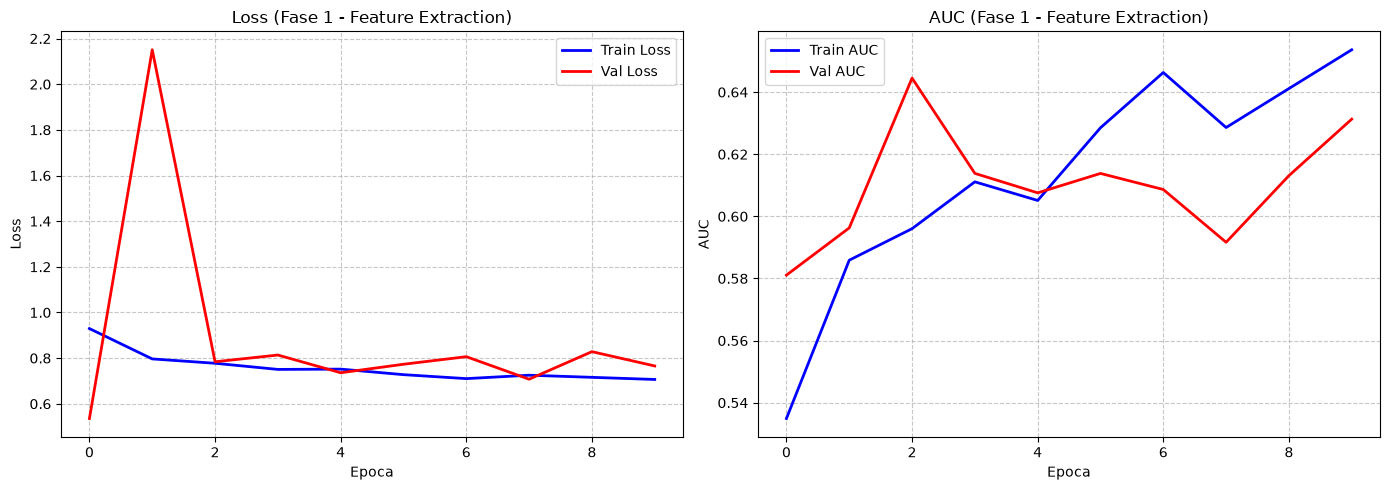

Grafico salvato in: ../experiments/exp_trad_aug_efficientnetb3/figures/training_history_fase2_efficientnetb3.png


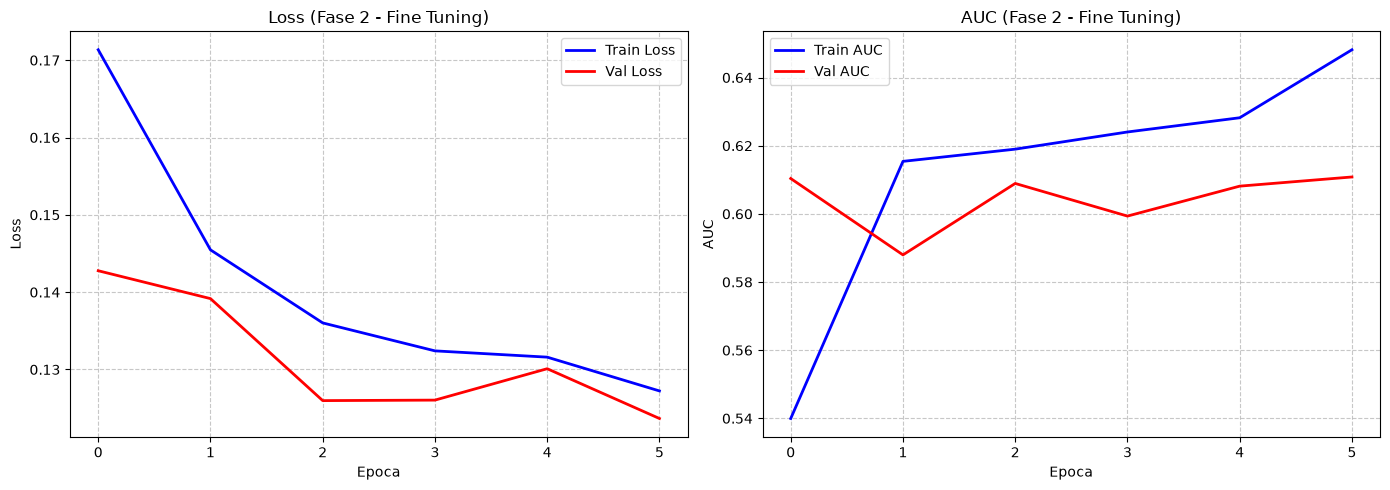

In [7]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title('Loss ' + title_suffix); ax1.set_xlabel('Epoca'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.7)
    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title('AUC ' + title_suffix); ax2.set_xlabel('Epoca'); ax2.set_ylabel('AUC')
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print("Grafico salvato in:", save_path)
    plt.show()

plot_training_history(history_phase1, "(Fase 1 - Feature Extraction)",
                      os.path.join(FIGURES_DIR, 'training_history_fase1_efficientnetb3.png'))
plot_training_history(history_phase2, "(Fase 2 - Fine Tuning)",
                      os.path.join(FIGURES_DIR, 'training_history_fase2_efficientnetb3.png'))

#### Valutazione sul TEST (soglia di Youden scelta sul VAL)

Le metriche ufficiali D2 vanno sul **TEST** held-out. La soglia ottimale (Youden's J) si sceglie
sul **VAL** e si applica al test: scegliere e riportare la soglia sullo stesso test darebbe un bias
ottimistico.

2026-06-16 16:35:50.167499: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Soglia di Youden (da VAL): 0.5645


2026-06-16 16:36:08.694037: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:36:08.946295: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:36:09.182822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 16:36:14.715218: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


AUC (test): 0.6569
              precision    recall  f1-score   support

        Sano       0.87      0.67      0.76       365
      Malato       0.24      0.51      0.32        73

    accuracy                           0.65       438
   macro avg       0.55      0.59      0.54       438
weighted avg       0.77      0.65      0.69       438

Metriche salvate in test_metrics_efficientnetb3.json


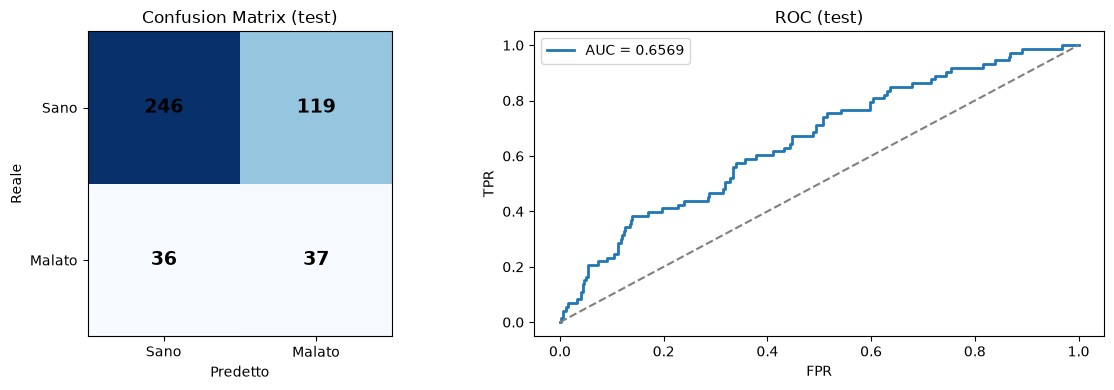

In [8]:
# Carica il miglior modello (Fase 2)
best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'trad_aug_efficientnetb3_final_best.keras'),
    custom_objects={'loss_fn': focal_loss(gamma=2.0, alpha=0.75)}
)

def predici(ds):
    yt, yp = [], []
    for imgs, labels in ds:
        yp.extend(best_model.predict(imgs, verbose=0).flatten())
        yt.extend(labels.numpy())
    return np.array(yt), np.array(yp)

# 1) Soglia di Youden dal VAL
val_true, val_prob = predici(val_ds)
fpr_v, tpr_v, thr_v = roc_curve(val_true, val_prob)
best_threshold = float(thr_v[np.argmax(tpr_v - fpr_v)])
print("Soglia di Youden (da VAL):", round(best_threshold, 4))

# 2) Inferenza sul TEST (misurata per la D3) + applica la soglia del val
with measure_sustainability(label="inference_trad_aug_efficientnetb3") as eco:
    test_true, test_prob = predici(test_ds)
eco_inf = eco.metrics
test_pred = (test_prob >= best_threshold).astype(int)

# 3) Metriche D2 sul TEST
auc = roc_auc_score(test_true, test_prob)
report = classification_report(test_true, test_pred, target_names=['Sano', 'Malato'])
print("AUC (test):", round(float(auc), 4))
print(report)

metrics_dict = {
    'arch': ARCH, 'config': CONFIG, 'split': 'test',
    'threshold_youden_from_val': round(best_threshold, 4),
    'roc_auc': round(float(auc), 4),
    'accuracy': round(float(accuracy_score(test_true, test_pred)), 4),
    'precision_malato': round(float(precision_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'recall_malato': round(float(recall_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'f1_malato': round(float(f1_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report,
}
with open(os.path.join(OUTPUT_DIR, 'test_metrics_efficientnetb3.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print("Metriche salvate in test_metrics_efficientnetb3.json")

# 4) Figura: confusion matrix + ROC (test)
cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Sano', 'Malato']); ax[0].set_yticklabels(['Sano', 'Malato'])
ax[0].set_xlabel('Predetto'); ax[0].set_ylabel('Reale'); ax[0].set_title('Confusion Matrix (test)')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
fpr_t, tpr_t, _ = roc_curve(test_true, test_prob)
ax[1].plot(fpr_t, tpr_t, lw=2, label='AUC = %.4f' % auc)
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC (test)'); ax[1].legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'test_confusion_roc_efficientnetb3.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Valutazione bilanciata a bootstrap (il test e' ~5:1)

Il test e' sbilanciato (365 Sani / 73 Malati). Tieni tutti i positivi, campiona pari negativi,
calcola le metriche su N round e media (media +/- std): evita l'accuracy gonfiata dallo sbilanciamento.

Accuracy   0.5918 +/- 0.0171
Precision  0.6116 +/- 0.0250
Recall     0.5068 +/- 0.0000
F1         0.5541 +/- 0.0103
ROC_AUC    0.6575 +/- 0.0265


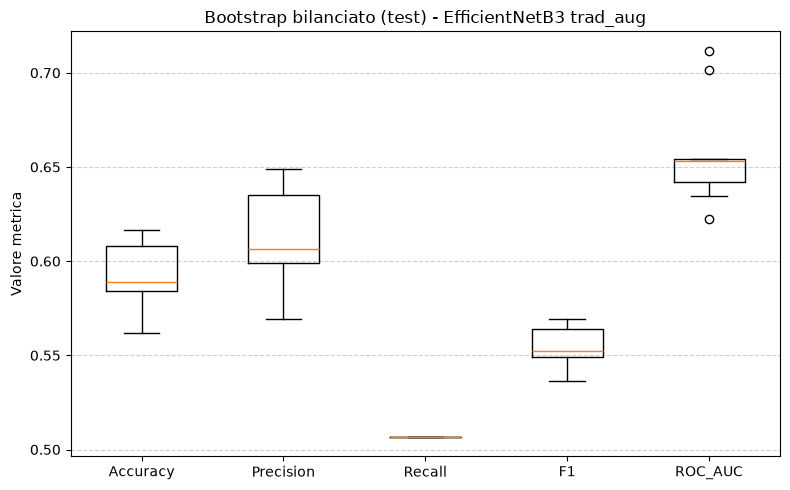

In [9]:
def bootstrap_bilanciato(y_true, y_prob, threshold, n_rounds=10, seed=SEED):
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n = min(len(pos_idx), len(neg_idx))
    out = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC_AUC': []}
    for _ in range(n_rounds):
        sel_neg = rng.choice(neg_idx, size=n, replace=False)
        idx = np.concatenate([pos_idx, sel_neg])
        yt, yp = y_true[idx], y_prob[idx]
        pred = (yp >= threshold).astype(int)
        out['Accuracy'].append(accuracy_score(yt, pred))
        out['Precision'].append(precision_score(yt, pred, pos_label=1, zero_division=0))
        out['Recall'].append(recall_score(yt, pred, pos_label=1, zero_division=0))
        out['F1'].append(f1_score(yt, pred, pos_label=1, zero_division=0))
        out['ROC_AUC'].append(roc_auc_score(yt, yp))
    for k, v in out.items():
        print("%-10s %.4f +/- %.4f" % (k, np.mean(v), np.std(v)))
    return out

boot = bootstrap_bilanciato(test_true, test_prob, best_threshold, n_rounds=10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(list(boot.values()))
ax.set_xticklabels(list(boot.keys()))
ax.set_title('Bootstrap bilanciato (test) - EfficientNetB3 trad_aug')
ax.set_ylabel('Valore metrica'); ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'bootstrap_efficientnetb3.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Sostenibilità (D3)

In [10]:
# Riepilogo D3: costo di training + inferenza. Saltato se eco_tracker non disponibile.
if ECO_OK and eco_train is not None and eco_inf is not None:
    eco_summary = {'arch': ARCH, 'config': CONFIG,
                   'training': eco_train.to_dict(), 'inference': eco_inf.to_dict()}
    print("TRAINING :", eco_train)
    print("INFERENCE:", eco_inf)
    with open(os.path.join(OUTPUT_DIR, 'eco_efficientnetb3.json'), 'w') as f:
        json.dump(eco_summary, f, indent=2, ensure_ascii=False)
    print("Eco salvato in eco_efficientnetb3.json")
else:
    print("Sostenibilita' non misurata (eco_tracker non disponibile in questo ambiente).")

Sostenibilita' non misurata (eco_tracker non disponibile in questo ambiente).
